<a href="https://colab.research.google.com/github/Farheen-18/AIProject/blob/main/AIprojectfinalWithGridSearchCV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving tweets.csv to tweets.csv
Dataset shape: (11370, 2)

Class distribution:
target
0    9256
1    2114
Name: count, dtype: int64

Class distribution (%):
target
0    81.407212
1    18.592788
Name: proportion, dtype: float64

Train shape: (9091, 5000)
Test shape : (2273, 5000)

--- Logistic Regression GridSearchCV ---
  Param grid : {'penalty': ['l1', 'l2'], 'C': [0.1, 1.0, 10.0], 'solver': ['liblinear']}
  Threshold  : 0.5
  Best params : {'C': 10.0, 'penalty': 'l2', 'solver': 'liblinear'}
  Best CV F1  : 0.7811

Logistic Regression
Accuracy            : 0.8737
Precision (class 0) : 0.903
Precision (class 1) : 0.7036
Recall (class 0)    : 0.9465
Recall (class 1)    : 0.5556
F1 Macro            : 0.7726
F1 Weighted         : 0.8678
ROC-AUC             : 0.8925
PR-AUC              : 0.7117

Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.90      0.95      0.92      1850
    Disaster       0.70      0.56      0.62       423

    accura

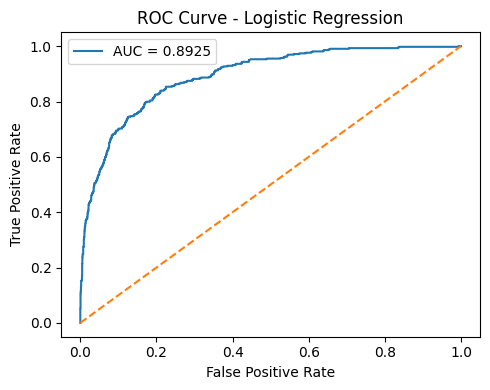

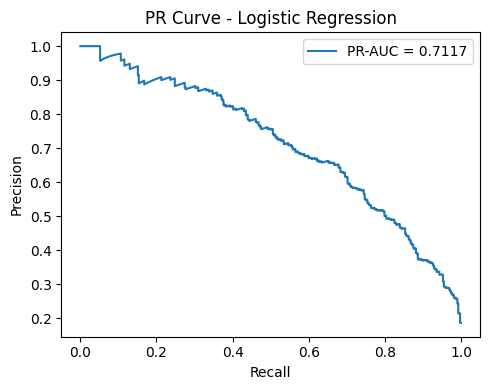


--- Random Forest GridSearchCV ---
  Param grid : {'n_estimators': [50, 100], 'max_depth': [10, 20], 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2]}
  Best params : {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
  Best CV F1  : 0.5451

Random Forest
Accuracy            : 0.8311
Precision (class 0) : 0.8284
Precision (class 1) : 0.9756
Recall (class 0)    : 0.9995
Recall (class 1)    : 0.0946
F1 Macro            : 0.5392
F1 Weighted         : 0.7694
ROC-AUC             : 0.8382
PR-AUC              : 0.6484

Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.83      1.00      0.91      1850
    Disaster       0.98      0.09      0.17       423

    accuracy                           0.83      2273
   macro avg       0.90      0.55      0.54      2273
weighted avg       0.86      0.83      0.77      2273

Confusion Matrix:
[[1849    1]
 [ 383   40]]


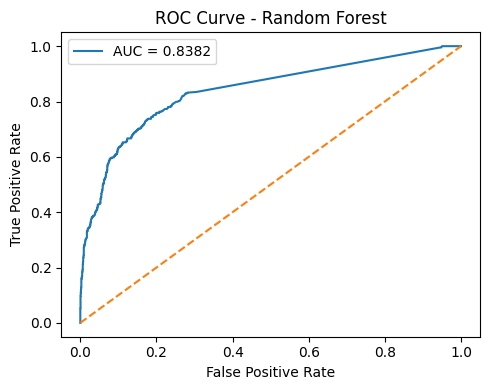

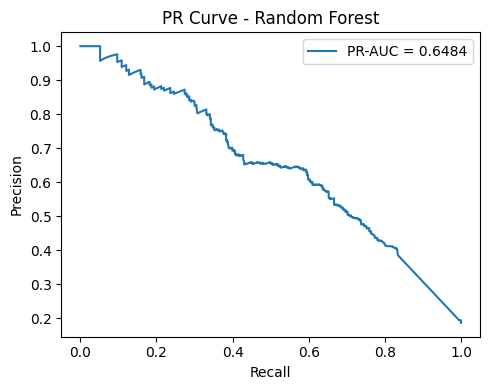


--- Neural Network Config ---
  Activation     : relu
  Learning Rate  : 0.001
  Optimizer      : adam
  Batch Size     : 64
  Epochs         : 20
  Dropout        : 0.3
  L2 Reg         : 0.0001
  Weight Init    : xavier
  Threshold      : 0.5

Training Neural Network...
  Epoch 5/20  Loss: 0.0848
  Epoch 10/20  Loss: 0.0224
  Epoch 15/20  Loss: 0.0181
  Epoch 20/20  Loss: 0.0173

Neural Network
Accuracy            : 0.8465
Precision (class 0) : 0.9204
Precision (class 1) : 0.5758
Recall (class 0)    : 0.8881
Recall (class 1)    : 0.6643
F1 Macro            : 0.7604
F1 Weighted         : 0.8506
ROC-AUC             : 0.86
PR-AUC              : 0.6739

Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.92      0.89      0.90      1850
    Disaster       0.58      0.66      0.62       423

    accuracy                           0.85      2273
   macro avg       0.75      0.78      0.76      2273
weighted avg       0.86      0.85      0.85 

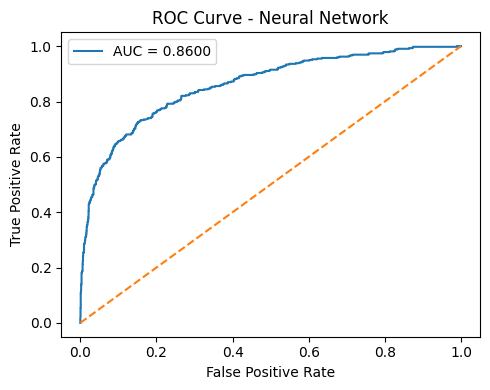

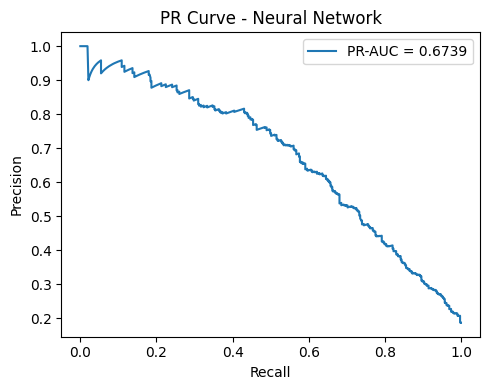


Part A completed successfully.


In [1]:
# ============================================================
# PART A: WITHOUT IMBALANCE HANDLING
# Models:
# 1. Logistic Regression (GridSearchCV)
# 2. Random Forest (GridSearchCV)
# 3. Neural Network (manual tuning)
# ============================================================

import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve, auc
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ------------------------------------------------------------
# 1. Load dataset
# ------------------------------------------------------------
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("tweets.csv")
df = df[["text", "target"]].dropna()

print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df["target"].value_counts())
print("\nClass distribution (%):")
print(df["target"].value_counts(normalize=True) * 100)

# ------------------------------------------------------------
# 2. Clean text
# ------------------------------------------------------------
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)
df = df[df["clean_text"].str.strip() != ""].reset_index(drop=True)

# ------------------------------------------------------------
# 3. Split data
# ------------------------------------------------------------
X = df["clean_text"]
y = df["target"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ------------------------------------------------------------
# 4. TF-IDF
# ------------------------------------------------------------
tfidf = TfidfVectorizer(stop_words="english", max_features=5000, ngram_range=(1, 2))
X_train = tfidf.fit_transform(X_train_text)
X_test  = tfidf.transform(X_test_text)

print("\nTrain shape:", X_train.shape)
print("Test shape :", X_test.shape)

# ------------------------------------------------------------
# 5. Evaluation function
# ------------------------------------------------------------
def evaluate_model(name, y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print("Accuracy            :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision (class 0) :", round(precision_score(y_true, y_pred, pos_label=0, zero_division=0), 4))
    print("Precision (class 1) :", round(precision_score(y_true, y_pred, pos_label=1, zero_division=0), 4))
    print("Recall (class 0)    :", round(recall_score(y_true, y_pred, pos_label=0, zero_division=0), 4))
    print("Recall (class 1)    :", round(recall_score(y_true, y_pred, pos_label=1, zero_division=0), 4))
    print("F1 Macro            :", round(f1_score(y_true, y_pred, average="macro", zero_division=0), 4))
    print("F1 Weighted         :", round(f1_score(y_true, y_pred, average="weighted", zero_division=0), 4))
    print("ROC-AUC             :", round(roc_auc_score(y_true, y_prob), 4))

    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall_curve, precision_curve)
    print("PR-AUC              :", round(pr_auc, 4))

    print("\nClassification Report:")
    print(classification_report(
        y_true, y_pred,
        target_names=["Not Disaster", "Disaster"],
        zero_division=0
    ))

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_true, y_prob):.4f}")
    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # PR Curve
    plt.figure(figsize=(5, 4))
    plt.plot(recall_curve, precision_curve, label=f"PR-AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"PR Curve - {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 6. Logistic Regression with GridSearchCV
# ------------------------------------------------------------
LR_THRESHOLD = 0.5

lr_param_grid = {
    "penalty": ["l1", "l2"],
    "C":       [0.1, 1.0, 10.0],
    "solver":  ["liblinear"]
}

print("\n--- Logistic Regression GridSearchCV ---")
print(f"  Param grid : {lr_param_grid}")
print(f"  Threshold  : {LR_THRESHOLD}")

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid=lr_param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)
lr_grid.fit(X_train, y_train)

print(f"  Best params : {lr_grid.best_params_}")
print(f"  Best CV F1  : {round(lr_grid.best_score_, 4)}")

lr_model = lr_grid.best_estimator_
lr_prob  = lr_model.predict_proba(X_test)[:, 1]
lr_prob_A = lr_prob.copy()
evaluate_model("Logistic Regression", y_test, lr_prob, threshold=LR_THRESHOLD)

# ------------------------------------------------------------
# 7. Random Forest with GridSearchCV
# ------------------------------------------------------------
rf_param_grid = {
    "n_estimators":      [50, 100],
    "max_depth":         [10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf":  [1, 2]
}

print("\n--- Random Forest GridSearchCV ---")
print(f"  Param grid : {rf_param_grid}")

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)

print(f"  Best params : {rf_grid.best_params_}")
print(f"  Best CV F1  : {round(rf_grid.best_score_, 4)}")

rf_model = rf_grid.best_estimator_
rf_prob  = rf_model.predict_proba(X_test)[:, 1]
rf_prob_A = rf_prob.copy()
evaluate_model("Random Forest", y_test, rf_prob, threshold=0.5)

# ------------------------------------------------------------
# 8. Neural Network (PyTorch) - manual tuning
# Fixed architecture: Input -> 64 -> 32 -> 16 -> Output
# ~~~~~~~~~~~~~~
# TUNABLE CONFIG
# ~~~~~~~~~~~~~~
ACTIVATION    = "relu"
LEARNING_RATE = 0.001
OPTIMIZER     = "adam"
BATCH_SIZE    = 64
EPOCHS        = 20
DROPOUT       = 0.3
L2_REG        = 1e-4
INIT          = "xavier"
NN_THRESHOLD  = 0.5
# ~~~~~~~~~~~~~~

print("\n--- Neural Network Config ---")
print(f"  Activation     : {ACTIVATION}")
print(f"  Learning Rate  : {LEARNING_RATE}")
print(f"  Optimizer      : {OPTIMIZER}")
print(f"  Batch Size     : {BATCH_SIZE}")
print(f"  Epochs         : {EPOCHS}")
print(f"  Dropout        : {DROPOUT}")
print(f"  L2 Reg         : {L2_REG}")
print(f"  Weight Init    : {INIT}")
print(f"  Threshold      : {NN_THRESHOLD}")

class TextNeuralNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        act_map = {
            "relu":      nn.ReLU(),
            "leakyrelu": nn.LeakyReLU(0.1),
            "tanh":      nn.Tanh(),
            "elu":       nn.ELU()
        }
        act = act_map.get(ACTIVATION, nn.ReLU())

        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 1)

        self.act     = act
        self.dropout = nn.Dropout(DROPOUT)

        for fc in [self.fc1, self.fc2, self.fc3, self.fc4]:
            if INIT == "xavier":
                nn.init.xavier_uniform_(fc.weight)
            elif INIT == "he":
                if ACTIVATION in ["relu", "leakyrelu"]:
                    nn.init.kaiming_uniform_(fc.weight, nonlinearity="relu")
                else:
                    nn.init.xavier_uniform_(fc.weight)
            elif INIT == "uniform":
                nn.init.uniform_(fc.weight, -0.1, 0.1)
            nn.init.zeros_(fc.bias)

    def forward(self, x):
        x = self.dropout(self.act(self.fc1(x)))
        x = self.dropout(self.act(self.fc2(x)))
        x = self.act(self.fc3(x))
        x = torch.sigmoid(self.fc4(x))
        return x.squeeze(1)

# Prepare tensors
X_train_dense  = X_train.toarray().astype(np.float32)
X_test_dense   = X_test.toarray().astype(np.float32)
X_train_tensor = torch.tensor(X_train_dense)
y_train_tensor = torch.tensor(y_train.to_numpy().astype(np.float32))
X_test_tensor  = torch.tensor(X_test_dense)

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True
)

nn_model  = TextNeuralNet(input_dim=X_train_dense.shape[1])
criterion = nn.BCELoss()
opt_map   = {
    "adam":    torch.optim.Adam(nn_model.parameters(),    lr=LEARNING_RATE, weight_decay=L2_REG),
    "sgd":     torch.optim.SGD(nn_model.parameters(),     lr=LEARNING_RATE, weight_decay=L2_REG),
    "rmsprop": torch.optim.RMSprop(nn_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_REG)
}
optimizer = opt_map.get(OPTIMIZER, torch.optim.Adam(nn_model.parameters(), lr=LEARNING_RATE))

print("\nTraining Neural Network...")
for epoch in range(EPOCHS):
    nn_model.train()
    total_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        loss = criterion(nn_model(batch_X), batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1}/{EPOCHS}  Loss: {total_loss/len(train_loader):.4f}")

nn_model.eval()
with torch.no_grad():
    nn_prob  = nn_model(X_test_tensor).cpu().numpy()
    nn_prob_A = nn_prob.copy()

evaluate_model("Neural Network", y_test, nn_prob, threshold=NN_THRESHOLD)

print("\nPart A completed successfully.")

Saving tweets.csv to tweets (1).csv
Dataset shape: (11370, 2)

Original class distribution:
target
0    9256
1    2114
Name: count, dtype: int64

Train shape: (9091, 5000)
Test shape : (2273, 5000)

--- Logistic Regression GridSearchCV (Class Weighting) ---
  Param grid : {'penalty': ['l1', 'l2'], 'C': [0.1, 1.0, 10.0], 'solver': ['liblinear']}
  Threshold  : 0.5
  Class Weight : balanced
  Best params : {'C': 10.0, 'penalty': 'l2', 'solver': 'liblinear'}
  Best CV F1  : 0.7809

Logistic Regression - Class Weighting
Accuracy            : 0.846
Precision (class 0) : 0.932
Precision (class 1) : 0.568
Recall (class 0)    : 0.8746
Recall (class 1)    : 0.721
F1 Macro            : 0.7689
F1 Weighted         : 0.8527
ROC-AUC             : 0.8892
PR-AUC              : 0.7026

Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.93      0.87      0.90      1850
    Disaster       0.57      0.72      0.64       423

    accuracy                     

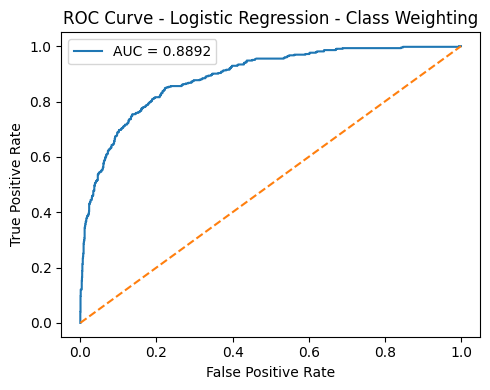

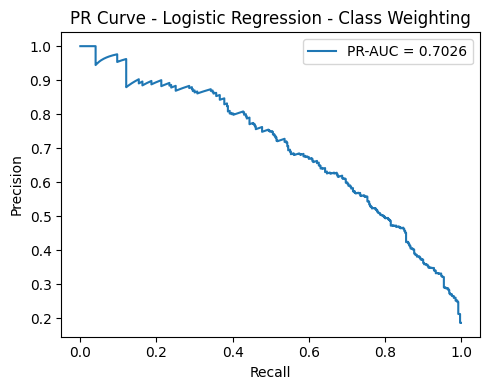


--- Random Forest GridSearchCV (Class Weighting) ---
  Param grid   : {'n_estimators': [50, 100], 'max_depth': [10, 20], 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2]}
  Class Weight : balanced
  Best params : {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
  Best CV F1  : 0.7396

Random Forest - Class Weighting
Accuracy            : 0.8605
Precision (class 0) : 0.8921
Precision (class 1) : 0.6667
Recall (class 0)    : 0.9427
Recall (class 1)    : 0.5012
F1 Macro            : 0.7444
F1 Weighted         : 0.8526
ROC-AUC             : 0.8477
PR-AUC              : 0.6404

Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.89      0.94      0.92      1850
    Disaster       0.67      0.50      0.57       423

    accuracy                           0.86      2273
   macro avg       0.78      0.72      0.74      2273
weighted avg       0.85      0.86      0.85      2273

Confusion Matrix:
[[1744 

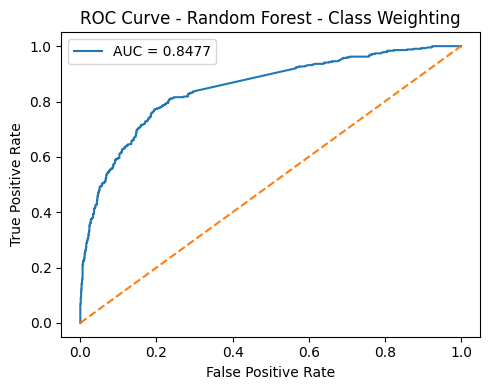

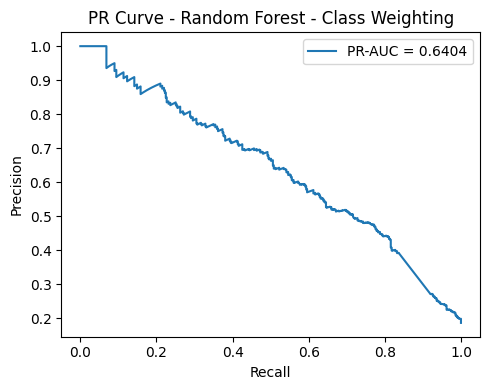


--- Neural Network Config ---
  Activation     : relu
  Learning Rate  : 0.001
  Optimizer      : adam
  Batch Size     : 64
  Epochs         : 20
  Dropout        : 0.3
  L2 Reg         : 0.0001
  Weight Init    : xavier
  Threshold      : 0.5
  Technique      : weighted BCE loss

Training Neural Network...
  Epoch 5/20  Loss: 0.0944
  Epoch 10/20  Loss: 0.0284
  Epoch 15/20  Loss: 0.0208
  Epoch 20/20  Loss: 0.0188

Neural Network - Class Weighting
Accuracy            : 0.8249
Precision (class 0) : 0.9236
Precision (class 1) : 0.5224
Recall (class 0)    : 0.8557
Recall (class 1)    : 0.6903
F1 Macro            : 0.7415
F1 Weighted         : 0.8337
ROC-AUC             : 0.8529
PR-AUC              : 0.6564

Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.92      0.86      0.89      1850
    Disaster       0.52      0.69      0.59       423

    accuracy                           0.82      2273
   macro avg       0.72      0.77      0.

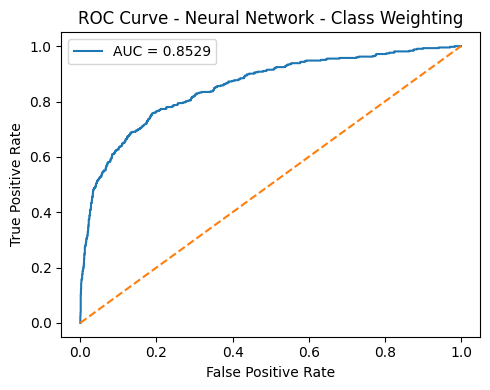

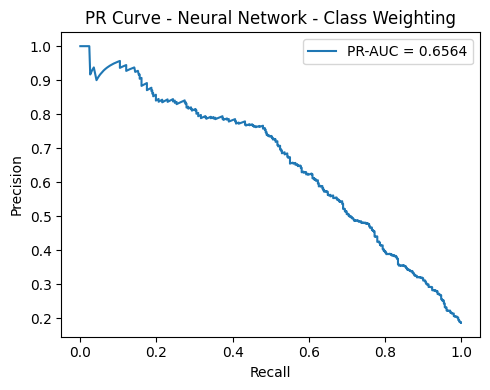


Technique 1 completed: Class Weighting


In [2]:
# ============================================================
# PART B - TECHNIQUE 1: CLASS WEIGHTING
# Models:
# 1. Logistic Regression (GridSearchCV)
# 2. Random Forest (GridSearchCV)
# 3. Neural Network (manual tuning)
# ============================================================

import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve, auc
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ------------------------------------------------------------
# 1. Load dataset
# ------------------------------------------------------------
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("tweets.csv")
df = df[["text", "target"]].dropna()

print("Dataset shape:", df.shape)
print("\nOriginal class distribution:")
print(df["target"].value_counts())

# ------------------------------------------------------------
# 2. Clean text
# ------------------------------------------------------------
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)
df = df[df["clean_text"].str.strip() != ""].reset_index(drop=True)

# ------------------------------------------------------------
# 3. Split data
# ------------------------------------------------------------
X = df["clean_text"]
y = df["target"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ------------------------------------------------------------
# 4. TF-IDF
# ------------------------------------------------------------
tfidf = TfidfVectorizer(stop_words="english", max_features=5000, ngram_range=(1, 2))
X_train = tfidf.fit_transform(X_train_text)
X_test  = tfidf.transform(X_test_text)

print("\nTrain shape:", X_train.shape)
print("Test shape :", X_test.shape)

# ------------------------------------------------------------
# 5. Evaluation function
# ------------------------------------------------------------
def evaluate_model(name, y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print("Accuracy            :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision (class 0) :", round(precision_score(y_true, y_pred, pos_label=0, zero_division=0), 4))
    print("Precision (class 1) :", round(precision_score(y_true, y_pred, pos_label=1, zero_division=0), 4))
    print("Recall (class 0)    :", round(recall_score(y_true, y_pred, pos_label=0, zero_division=0), 4))
    print("Recall (class 1)    :", round(recall_score(y_true, y_pred, pos_label=1, zero_division=0), 4))
    print("F1 Macro            :", round(f1_score(y_true, y_pred, average="macro", zero_division=0), 4))
    print("F1 Weighted         :", round(f1_score(y_true, y_pred, average="weighted", zero_division=0), 4))
    print("ROC-AUC             :", round(roc_auc_score(y_true, y_prob), 4))

    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall_curve, precision_curve)
    print("PR-AUC              :", round(pr_auc, 4))

    print("\nClassification Report:")
    print(classification_report(
        y_true, y_pred,
        target_names=["Not Disaster", "Disaster"],
        zero_division=0
    ))

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_true, y_prob):.4f}")
    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # PR Curve
    plt.figure(figsize=(5, 4))
    plt.plot(recall_curve, precision_curve, label=f"PR-AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"PR Curve - {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 6. Logistic Regression with GridSearchCV + class weighting
# ------------------------------------------------------------
LR_THRESHOLD = 0.5

lr_param_grid = {
    "penalty": ["l1", "l2"],
    "C":       [0.1, 1.0, 10.0],
    "solver":  ["liblinear"]
}

print("\n--- Logistic Regression GridSearchCV (Class Weighting) ---")
print(f"  Param grid : {lr_param_grid}")
print(f"  Threshold  : {LR_THRESHOLD}")
print("  Class Weight : balanced")

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"),
    param_grid=lr_param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)
lr_grid.fit(X_train, y_train)

print(f"  Best params : {lr_grid.best_params_}")
print(f"  Best CV F1  : {round(lr_grid.best_score_, 4)}")

lr_model  = lr_grid.best_estimator_
lr_prob   = lr_model.predict_proba(X_test)[:, 1]
lr_prob_CW = lr_prob.copy()
evaluate_model("Logistic Regression - Class Weighting", y_test, lr_prob, threshold=LR_THRESHOLD)

# ------------------------------------------------------------
# 7. Random Forest with GridSearchCV + class weighting
# ------------------------------------------------------------
rf_param_grid = {
    "n_estimators":      [50, 100],
    "max_depth":         [10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf":  [1, 2]
}

print("\n--- Random Forest GridSearchCV (Class Weighting) ---")
print(f"  Param grid   : {rf_param_grid}")
print("  Class Weight : balanced")

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced"),
    param_grid=rf_param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)

print(f"  Best params : {rf_grid.best_params_}")
print(f"  Best CV F1  : {round(rf_grid.best_score_, 4)}")

rf_model  = rf_grid.best_estimator_
rf_prob   = rf_model.predict_proba(X_test)[:, 1]
rf_prob_CW = rf_prob.copy()
evaluate_model("Random Forest - Class Weighting", y_test, rf_prob, threshold=0.5)

# ------------------------------------------------------------
# 8. Neural Network with weighted BCE loss - manual tuning
# Fixed architecture: Input -> 64 -> 32 -> 16 -> Output
# ~~~~~~~~~~~~~~
# TUNABLE CONFIG
# ~~~~~~~~~~~~~~
ACTIVATION    = "relu"
LEARNING_RATE = 0.001
OPTIMIZER     = "adam"
BATCH_SIZE    = 64
EPOCHS        = 20
DROPOUT       = 0.3
L2_REG        = 1e-4
INIT          = "xavier"
NN_THRESHOLD  = 0.5
# ~~~~~~~~~~~~~~

print("\n--- Neural Network Config ---")
print(f"  Activation     : {ACTIVATION}")
print(f"  Learning Rate  : {LEARNING_RATE}")
print(f"  Optimizer      : {OPTIMIZER}")
print(f"  Batch Size     : {BATCH_SIZE}")
print(f"  Epochs         : {EPOCHS}")
print(f"  Dropout        : {DROPOUT}")
print(f"  L2 Reg         : {L2_REG}")
print(f"  Weight Init    : {INIT}")
print(f"  Threshold      : {NN_THRESHOLD}")
print("  Technique      : weighted BCE loss")

class TextNeuralNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        act_map = {
            "relu":      nn.ReLU(),
            "leakyrelu": nn.LeakyReLU(0.1),
            "tanh":      nn.Tanh(),
            "elu":       nn.ELU()
        }
        act = act_map.get(ACTIVATION, nn.ReLU())

        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 1)

        self.act     = act
        self.dropout = nn.Dropout(DROPOUT)

        for fc in [self.fc1, self.fc2, self.fc3, self.fc4]:
            if INIT == "xavier":
                nn.init.xavier_uniform_(fc.weight)
            elif INIT == "he":
                if ACTIVATION in ["relu", "leakyrelu"]:
                    nn.init.kaiming_uniform_(fc.weight, nonlinearity="relu")
                else:
                    nn.init.xavier_uniform_(fc.weight)
            elif INIT == "uniform":
                nn.init.uniform_(fc.weight, -0.1, 0.1)
            nn.init.zeros_(fc.bias)

    def forward(self, x):
        x = self.dropout(self.act(self.fc1(x)))
        x = self.dropout(self.act(self.fc2(x)))
        x = self.act(self.fc3(x))
        x = torch.sigmoid(self.fc4(x))
        return x.squeeze(1)

# Prepare tensors
X_train_dense  = X_train.toarray().astype(np.float32)
X_test_dense   = X_test.toarray().astype(np.float32)
X_train_tensor = torch.tensor(X_train_dense)
y_train_tensor = torch.tensor(y_train.to_numpy().astype(np.float32))
X_test_tensor  = torch.tensor(X_test_dense)

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True
)

nn_model = TextNeuralNet(input_dim=X_train_dense.shape[1])

# Compute class weights
class_counts = y_train.value_counts().sort_index()
count_0  = class_counts[0]
count_1  = class_counts[1]
weight_0 = len(y_train) / (2 * count_0)
weight_1 = len(y_train) / (2 * count_1)

criterion = nn.BCELoss(reduction="none")

opt_map = {
    "adam":    torch.optim.Adam(nn_model.parameters(),    lr=LEARNING_RATE, weight_decay=L2_REG),
    "sgd":     torch.optim.SGD(nn_model.parameters(),     lr=LEARNING_RATE, weight_decay=L2_REG),
    "rmsprop": torch.optim.RMSprop(nn_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_REG)
}
optimizer = opt_map.get(OPTIMIZER, torch.optim.Adam(nn_model.parameters(), lr=LEARNING_RATE))

print("\nTraining Neural Network...")
for epoch in range(EPOCHS):
    nn_model.train()
    total_loss = 0.0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = nn_model(batch_X)

        sample_weights = torch.where(
            batch_y == 1,
            torch.tensor(weight_1, dtype=torch.float32),
            torch.tensor(weight_0, dtype=torch.float32)
        )

        loss = criterion(outputs, batch_y)
        loss = (loss * sample_weights).mean()

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1}/{EPOCHS}  Loss: {total_loss/len(train_loader):.4f}")

nn_model.eval()
with torch.no_grad():
    nn_prob   = nn_model(X_test_tensor).cpu().numpy()
    nn_prob_CW = nn_prob.copy()

evaluate_model("Neural Network - Class Weighting", y_test, nn_prob, threshold=NN_THRESHOLD)

print("\nTechnique 1 completed: Class Weighting")

Saving tweets.csv to tweets (2).csv
Dataset shape: (11370, 2)

Original class distribution:
target
0    9256
1    2114
Name: count, dtype: int64

Before oversampling (training only):
target
0    7400
1    1691
Name: count, dtype: int64

After oversampling (training only):
target
1    7400
0    7400
Name: count, dtype: int64

Train shape: (14800, 5000)
Test shape : (2273, 5000)

--- Logistic Regression GridSearchCV (Random Oversampling) ---
  Param grid : {'penalty': ['l1', 'l2'], 'C': [0.1, 1.0, 10.0], 'solver': ['liblinear']}
  Threshold  : 0.5
  Best params : {'C': 10.0, 'penalty': 'l1', 'solver': 'liblinear'}
  Best CV F1  : 0.9275

Logistic Regression - Random Oversampling
Accuracy            : 0.8478
Precision (class 0) : 0.9178
Precision (class 1) : 0.5814
Recall (class 0)    : 0.893
Recall (class 1)    : 0.6501
F1 Macro            : 0.7595
F1 Weighted         : 0.851
ROC-AUC             : 0.8573
PR-AUC              : 0.627

Classification Report:
              precision    recal

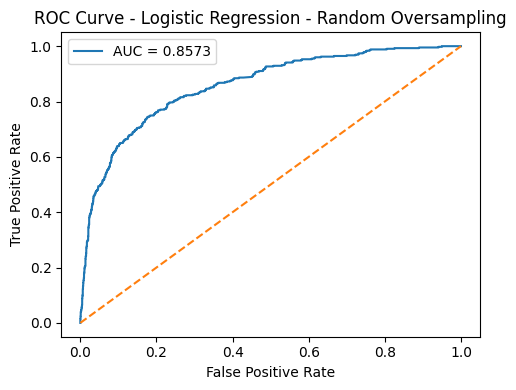

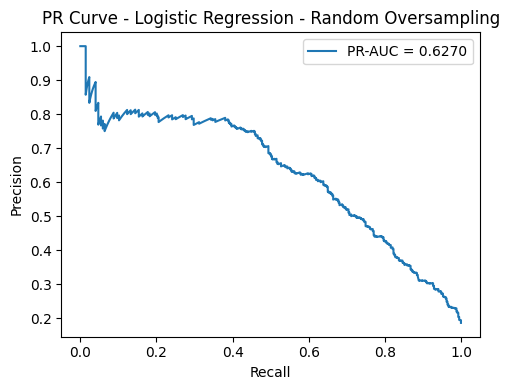


--- Random Forest GridSearchCV (Random Oversampling) ---
  Param grid : {'n_estimators': [50, 100], 'max_depth': [10, 20], 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2]}
  Best params : {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
  Best CV F1  : 0.7816

Random Forest - Random Oversampling
Accuracy            : 0.861
Precision (class 0) : 0.8909
Precision (class 1) : 0.672
Recall (class 0)    : 0.9449
Recall (class 1)    : 0.4941
F1 Macro            : 0.7433
F1 Weighted         : 0.8524
ROC-AUC             : 0.8457
PR-AUC              : 0.6452

Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.89      0.94      0.92      1850
    Disaster       0.67      0.49      0.57       423

    accuracy                           0.86      2273
   macro avg       0.78      0.72      0.74      2273
weighted avg       0.85      0.86      0.85      2273

Confusion Matrix:
[[1748  102]
 [ 214  209]]


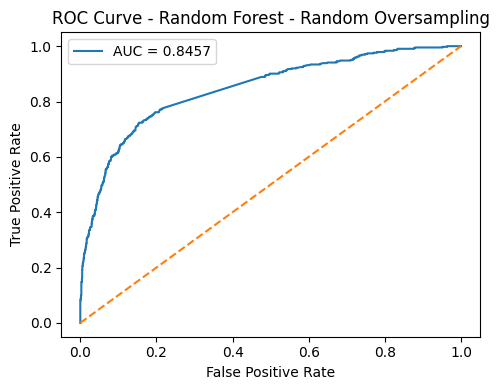

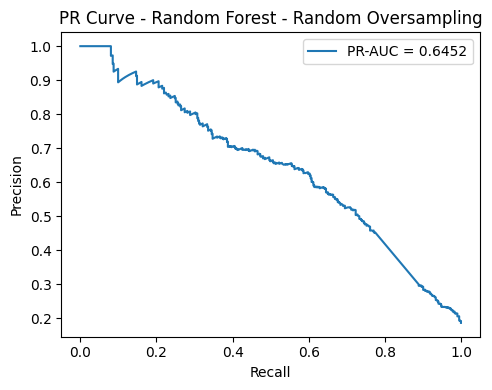


--- Neural Network Config ---
  Activation     : relu
  Learning Rate  : 0.001
  Optimizer      : adam
  Batch Size     : 64
  Epochs         : 20
  Dropout        : 0.3
  L2 Reg         : 0.0001
  Weight Init    : xavier
  Threshold      : 0.5

Training Neural Network...
  Epoch 5/20  Loss: 0.0347
  Epoch 10/20  Loss: 0.0179
  Epoch 15/20  Loss: 0.0146
  Epoch 20/20  Loss: 0.0123

Neural Network - Random Oversampling
Accuracy            : 0.8649
Precision (class 0) : 0.9168
Precision (class 1) : 0.6374
Recall (class 0)    : 0.9173
Recall (class 1)    : 0.6359
F1 Macro            : 0.7769
F1 Weighted         : 0.8649
ROC-AUC             : 0.8684
PR-AUC              : 0.6786

Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.92      0.92      0.92      1850
    Disaster       0.64      0.64      0.64       423

    accuracy                           0.86      2273
   macro avg       0.78      0.78      0.78      2273
weighted avg       0

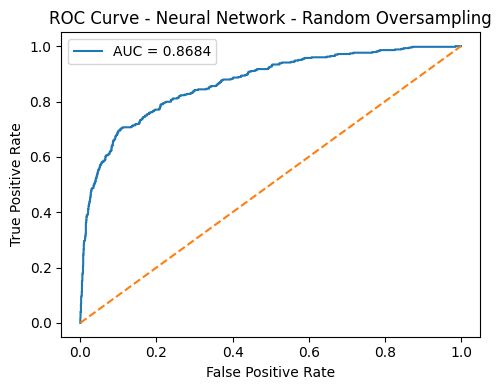

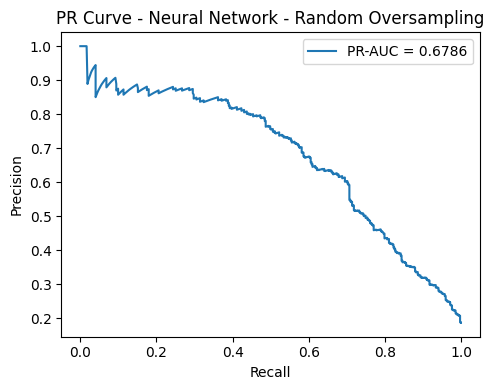


Technique 2 completed: Random Oversampling


In [3]:
# ============================================================
# PART B - TECHNIQUE 2: RANDOM OVERSAMPLING
# Models:
# 1. Logistic Regression (GridSearchCV)
# 2. Random Forest (GridSearchCV)
# 3. Neural Network (manual tuning)
# ============================================================

import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve, auc
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ------------------------------------------------------------
# 1. Load dataset
# ------------------------------------------------------------
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("tweets.csv")
df = df[["text", "target"]].dropna()

print("Dataset shape:", df.shape)
print("\nOriginal class distribution:")
print(df["target"].value_counts())

# ------------------------------------------------------------
# 2. Clean text
# ------------------------------------------------------------
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)
df = df[df["clean_text"].str.strip() != ""].reset_index(drop=True)

# ------------------------------------------------------------
# 3. Split data FIRST
# ------------------------------------------------------------
X = df["clean_text"]
y = df["target"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nBefore oversampling (training only):")
print(y_train.value_counts())

# ------------------------------------------------------------
# 4. Random oversampling on training data only
# ------------------------------------------------------------
train_df = pd.DataFrame({
    "clean_text": X_train_text.values,
    "target":     y_train.values
})

train_majority = train_df[train_df["target"] == 0]
train_minority = train_df[train_df["target"] == 1]

if len(train_majority) > len(train_minority):
    train_minority_upsampled = resample(
        train_minority,
        replace=True,
        n_samples=len(train_majority),
        random_state=42
    )
    train_balanced = pd.concat([train_majority, train_minority_upsampled])
else:
    train_majority_upsampled = resample(
        train_majority,
        replace=True,
        n_samples=len(train_minority),
        random_state=42
    )
    train_balanced = pd.concat([train_majority_upsampled, train_minority])

train_balanced = train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

X_train_text = train_balanced["clean_text"]
y_train      = train_balanced["target"]

print("\nAfter oversampling (training only):")
print(y_train.value_counts())

# ------------------------------------------------------------
# 5. TF-IDF
# ------------------------------------------------------------
tfidf = TfidfVectorizer(stop_words="english", max_features=5000, ngram_range=(1, 2))
X_train = tfidf.fit_transform(X_train_text)
X_test  = tfidf.transform(X_test_text)

print("\nTrain shape:", X_train.shape)
print("Test shape :", X_test.shape)

# ------------------------------------------------------------
# 6. Evaluation function
# ------------------------------------------------------------
def evaluate_model(name, y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print("Accuracy            :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision (class 0) :", round(precision_score(y_true, y_pred, pos_label=0, zero_division=0), 4))
    print("Precision (class 1) :", round(precision_score(y_true, y_pred, pos_label=1, zero_division=0), 4))
    print("Recall (class 0)    :", round(recall_score(y_true, y_pred, pos_label=0, zero_division=0), 4))
    print("Recall (class 1)    :", round(recall_score(y_true, y_pred, pos_label=1, zero_division=0), 4))
    print("F1 Macro            :", round(f1_score(y_true, y_pred, average="macro", zero_division=0), 4))
    print("F1 Weighted         :", round(f1_score(y_true, y_pred, average="weighted", zero_division=0), 4))
    print("ROC-AUC             :", round(roc_auc_score(y_true, y_prob), 4))

    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall_curve, precision_curve)
    print("PR-AUC              :", round(pr_auc, 4))

    print("\nClassification Report:")
    print(classification_report(
        y_true, y_pred,
        target_names=["Not Disaster", "Disaster"],
        zero_division=0
    ))

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_true, y_prob):.4f}")
    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # PR Curve
    plt.figure(figsize=(5, 4))
    plt.plot(recall_curve, precision_curve, label=f"PR-AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"PR Curve - {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 7. Logistic Regression with GridSearchCV
# ------------------------------------------------------------
LR_THRESHOLD = 0.5

lr_param_grid = {
    "penalty": ["l1", "l2"],
    "C":       [0.1, 1.0, 10.0],
    "solver":  ["liblinear"]
}

print("\n--- Logistic Regression GridSearchCV (Random Oversampling) ---")
print(f"  Param grid : {lr_param_grid}")
print(f"  Threshold  : {LR_THRESHOLD}")

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid=lr_param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)
lr_grid.fit(X_train, y_train)

print(f"  Best params : {lr_grid.best_params_}")
print(f"  Best CV F1  : {round(lr_grid.best_score_, 4)}")

lr_model   = lr_grid.best_estimator_
lr_prob    = lr_model.predict_proba(X_test)[:, 1]
lr_prob_ROS = lr_prob.copy()
evaluate_model("Logistic Regression - Random Oversampling", y_test, lr_prob, threshold=LR_THRESHOLD)

# ------------------------------------------------------------
# 8. Random Forest with GridSearchCV
# ------------------------------------------------------------
rf_param_grid = {
    "n_estimators":      [50, 100],
    "max_depth":         [10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf":  [1, 2]
}

print("\n--- Random Forest GridSearchCV (Random Oversampling) ---")
print(f"  Param grid : {rf_param_grid}")

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)

print(f"  Best params : {rf_grid.best_params_}")
print(f"  Best CV F1  : {round(rf_grid.best_score_, 4)}")

rf_model    = rf_grid.best_estimator_
rf_prob     = rf_model.predict_proba(X_test)[:, 1]
rf_prob_ROS = rf_prob.copy()
evaluate_model("Random Forest - Random Oversampling", y_test, rf_prob, threshold=0.5)

# ------------------------------------------------------------
# 9. Neural Network - manual tuning
# Fixed architecture: Input -> 64 -> 32 -> 16 -> Output
# ~~~~~~~~~~~~~~
# TUNABLE CONFIG
# ~~~~~~~~~~~~~~
ACTIVATION    = "relu"
LEARNING_RATE = 0.001
OPTIMIZER     = "adam"
BATCH_SIZE    = 64
EPOCHS        = 20
DROPOUT       = 0.3
L2_REG        = 1e-4
INIT          = "xavier"
NN_THRESHOLD  = 0.5
# ~~~~~~~~~~~~~~

print("\n--- Neural Network Config ---")
print(f"  Activation     : {ACTIVATION}")
print(f"  Learning Rate  : {LEARNING_RATE}")
print(f"  Optimizer      : {OPTIMIZER}")
print(f"  Batch Size     : {BATCH_SIZE}")
print(f"  Epochs         : {EPOCHS}")
print(f"  Dropout        : {DROPOUT}")
print(f"  L2 Reg         : {L2_REG}")
print(f"  Weight Init    : {INIT}")
print(f"  Threshold      : {NN_THRESHOLD}")

class TextNeuralNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        act_map = {
            "relu":      nn.ReLU(),
            "leakyrelu": nn.LeakyReLU(0.1),
            "tanh":      nn.Tanh(),
            "elu":       nn.ELU()
        }
        act = act_map.get(ACTIVATION, nn.ReLU())

        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 1)

        self.act     = act
        self.dropout = nn.Dropout(DROPOUT)

        for fc in [self.fc1, self.fc2, self.fc3, self.fc4]:
            if INIT == "xavier":
                nn.init.xavier_uniform_(fc.weight)
            elif INIT == "he":
                if ACTIVATION in ["relu", "leakyrelu"]:
                    nn.init.kaiming_uniform_(fc.weight, nonlinearity="relu")
                else:
                    nn.init.xavier_uniform_(fc.weight)
            elif INIT == "uniform":
                nn.init.uniform_(fc.weight, -0.1, 0.1)
            nn.init.zeros_(fc.bias)

    def forward(self, x):
        x = self.dropout(self.act(self.fc1(x)))
        x = self.dropout(self.act(self.fc2(x)))
        x = self.act(self.fc3(x))
        x = torch.sigmoid(self.fc4(x))
        return x.squeeze(1)

# Prepare tensors
X_train_dense  = X_train.toarray().astype(np.float32)
X_test_dense   = X_test.toarray().astype(np.float32)
X_train_tensor = torch.tensor(X_train_dense)
y_train_tensor = torch.tensor(y_train.to_numpy().astype(np.float32))
X_test_tensor  = torch.tensor(X_test_dense)

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True
)

nn_model  = TextNeuralNet(input_dim=X_train_dense.shape[1])
criterion = nn.BCELoss()

opt_map = {
    "adam":    torch.optim.Adam(nn_model.parameters(),    lr=LEARNING_RATE, weight_decay=L2_REG),
    "sgd":     torch.optim.SGD(nn_model.parameters(),     lr=LEARNING_RATE, weight_decay=L2_REG),
    "rmsprop": torch.optim.RMSprop(nn_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_REG)
}
optimizer = opt_map.get(OPTIMIZER, torch.optim.Adam(nn_model.parameters(), lr=LEARNING_RATE))

print("\nTraining Neural Network...")
for epoch in range(EPOCHS):
    nn_model.train()
    total_loss = 0.0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = nn_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1}/{EPOCHS}  Loss: {total_loss/len(train_loader):.4f}")

nn_model.eval()
with torch.no_grad():
    nn_prob     = nn_model(X_test_tensor).cpu().numpy()
    nn_prob_ROS = nn_prob.copy()

evaluate_model("Neural Network - Random Oversampling", y_test, nn_prob, threshold=NN_THRESHOLD)

print("\nTechnique 2 completed: Random Oversampling")


FINAL COMPARISON TABLE


,Model,Accuracy,Precision (Class 0),Precision (Class 1),Recall (Class 0),Recall (Class 1),F1 Macro,F1 Weighted,ROC-AUC,PR-AUC,Confusion Matrix
0,Part A - Logistic Regression,0.8737,0.9030,0.7036,0.9465,0.5556,0.7726,0.8678,0.8925,0.7117,TN:1751 FP:99 | FN:188 TP:235
1,Part A - Random Forest,0.8311,0.8284,0.9756,0.9995,0.0946,0.5392,0.7694,0.8382,0.6484,TN:1849 FP:1 | FN:383 TP:40
2,Part A - Neural Network,0.8465,0.9204,0.5758,0.8881,0.6643,0.7604,0.8506,0.8600,0.6739,TN:1643 FP:207 | FN:142 TP:281
3,Part B (Class Weighting) - Logistic Regression,0.8460,0.9320,0.5680,0.8746,0.7210,0.7689,0.8527,0.8892,0.7026,TN:1618 FP:232 | FN:118 TP:305
4,Part B (Class Weighting) - Random Forest,0.8605,0.8921,0.6667,0.9427,0.5012,0.7444,0.8526,0.8477,0.6404,TN:1744 FP:106 | FN:211 TP:212
5,Part B (Class Weighting) - Neural Network,0.8249,0.9236,0.5224,0.8557,0.6903,0.7415,0.8337,0.8529,0.6564,TN:1583 FP:267 | FN:131 TP:292
6,Part B (Oversampling) - Logistic Regression,0.8478,0.9178,0.5814,0.8930,0.6501,0.7595,0.8510,0.8573,0.6270,TN:1652 FP:198 | FN:148 TP:275
7,Part B (Oversampling) - Random Forest,0.8610,0.8909,0.6720,0.9449,0.4941,0.7433,0.8524,0.8457,0.6452,TN:1748 FP:102 | FN:214 TP:209
8,Part B (Oversampling) - Neural Network,0.8649,0.9168,0.6374,0.9173,0.6359,0.7769,0.8649,0.8684,0.6786,TN:1697 FP:153 | FN:154 TP:269


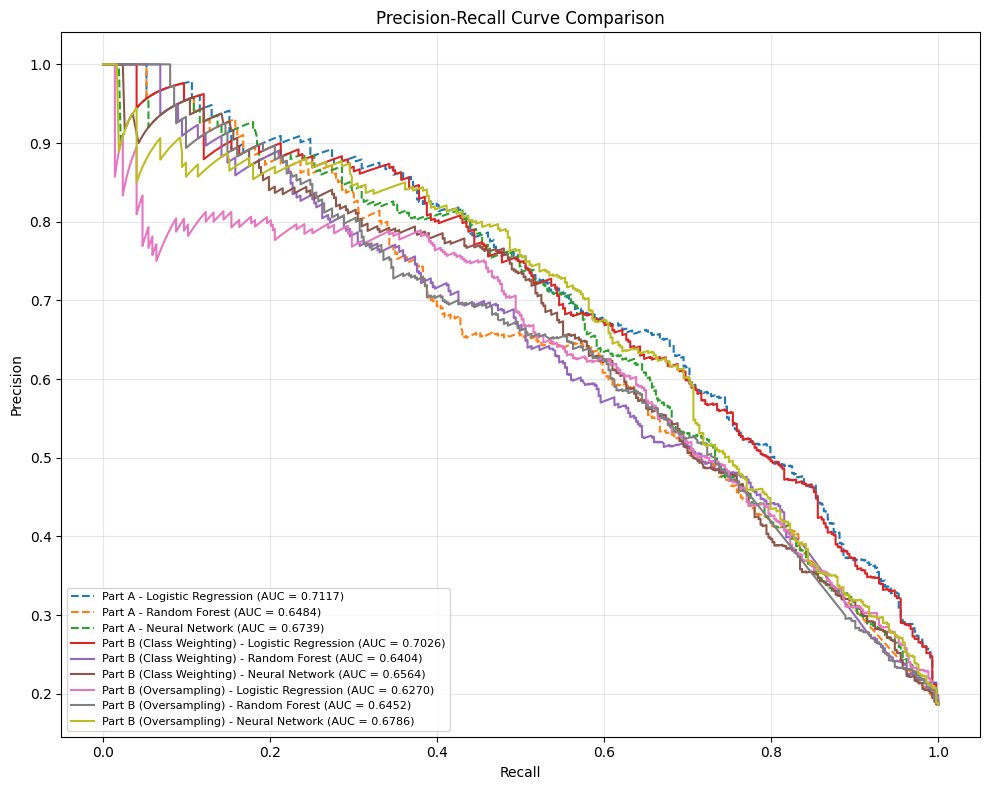

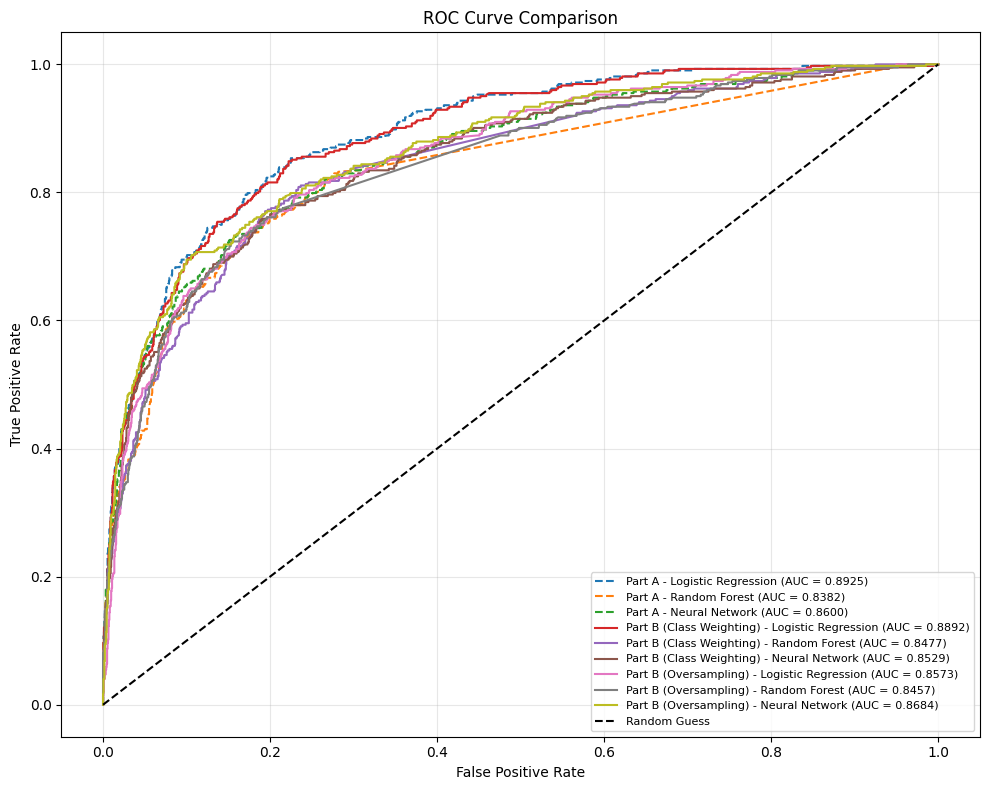

In [4]:
# ============================================================
# PART C: FINAL COMPARISON
# Part A vs Part B (Class Weighting) vs Part B (Random Oversampling)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, precision_recall_curve, auc, roc_curve
)

# ------------------------------------------------------------
# 1. Put all saved probability outputs here
# ------------------------------------------------------------
model_results = {
    "Part A - Logistic Regression": lr_prob_A,
    "Part A - Random Forest": rf_prob_A,
    "Part A - Neural Network": nn_prob_A,

    "Part B (Class Weighting) - Logistic Regression": lr_prob_CW,
    "Part B (Class Weighting) - Random Forest": rf_prob_CW,
    "Part B (Class Weighting) - Neural Network": nn_prob_CW,

    "Part B (Oversampling) - Logistic Regression": lr_prob_ROS,
    "Part B (Oversampling) - Random Forest": rf_prob_ROS,
    "Part B (Oversampling) - Neural Network": nn_prob_ROS
}

comparison_data = []
pr_plot_data = {}
roc_plot_data = {}

# ------------------------------------------------------------
# 2. Calculate metrics
# ------------------------------------------------------------
for name, y_prob in model_results.items():
    y_pred = (y_prob >= 0.5).astype(int)

    acc    = accuracy_score(y_test, y_pred)
    prec_0 = precision_score(y_test, y_pred, pos_label=0, zero_division=0)
    prec_1 = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    rec_0  = recall_score(y_test, y_pred, pos_label=0, zero_division=0)
    rec_1  = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1_mac = f1_score(y_test, y_pred, average="macro", zero_division=0)
    f1_wt  = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)

    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    pr_plot_data[name]  = (recall, precision, pr_auc)
    roc_plot_data[name] = (fpr, tpr, roc_auc)

    cm = confusion_matrix(y_test, y_pred)
    cm_str = f"TN:{cm[0,0]} FP:{cm[0,1]} | FN:{cm[1,0]} TP:{cm[1,1]}"

    comparison_data.append({
        "Model":                name,
        "Accuracy":             round(acc,     4),
        "Precision (Class 0)":  round(prec_0,  4),
        "Precision (Class 1)":  round(prec_1,  4),
        "Recall (Class 0)":     round(rec_0,   4),
        "Recall (Class 1)":     round(rec_1,   4),
        "F1 Macro":             round(f1_mac,  4),
        "F1 Weighted":          round(f1_wt,   4),
        "ROC-AUC":              round(roc_auc, 4),
        "PR-AUC":               round(pr_auc,  4),
        "Confusion Matrix":     cm_str
    })

# ------------------------------------------------------------
# 3. Comparison table
# ------------------------------------------------------------
df_comparison = pd.DataFrame(comparison_data)

print("\n" + "=" * 100)
print("FINAL COMPARISON TABLE")
print("=" * 100)
display(df_comparison)

# ------------------------------------------------------------
# 4. Precision-Recall Curve Comparison
# ------------------------------------------------------------
plt.figure(figsize=(10, 8))

for name, (recall, precision, pr_auc) in pr_plot_data.items():
    linestyle = "--" if "Part A" in name else "-"
    plt.plot(recall, precision, linestyle=linestyle, label=f"{name} (AUC = {pr_auc:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend(loc="lower left", fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. ROC Curve Comparison
# ------------------------------------------------------------
plt.figure(figsize=(10, 8))

for name, (fpr, tpr, roc_auc) in roc_plot_data.items():
    linestyle = "--" if "Part A" in name else "-"
    plt.plot(fpr, tpr, linestyle=linestyle, label=f"{name} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right", fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()